# File Import

In [2]:
#from google.colab import drive
#drive.mount("/content/gdrive")

In [3]:
#import os
#import pickle

#root_dir = "/content/gdrive/MyDrive/머신러닝/homework"

# Checking if our specified directory exists
#print(os.path.exists(root_dir))

In [6]:
#import pandas as pd

# Paths to the downloaded files
#train_data_path = os.path.join(root_dir, "train.csv")
#test_data_path = os.path.join(root_dir, "test.csv")

# Load data
#df = pd.read_csv(train_data_path)
#df_test = pd.read_csv(test_data_path)

In [8]:
import pandas as pd

df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [10]:
# Check the first few rows of the dataframe
print(df.head())
print(df_test.head())

      id  age          job   marital            education default  housing  \
0  19495   36   technician   married    university.degree      no      yes   
1  38793   28       admin.    single    university.degree      no      yes   
2  27160   57   management  divorced  professional.course      no      yes   
3  36476   24  blue-collar    single             basic.9y      no  unknown   
4  38007   24      student    single             basic.9y      no  unknown   

      loan   contact month  ... campaign  pdays  previous     poutcome  \
0      yes  cellular   aug  ...        1    999         0  nonexistent   
1       no  cellular   nov  ...        2    999         0  nonexistent   
2       no  cellular   nov  ...        1    999         0  nonexistent   
3  unknown  cellular   jun  ...        1    999         0  nonexistent   
4  unknown  cellular   sep  ...        1    999         0  nonexistent   

  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed    y  
0        

# Data Preprocessing

### Train Set Input/Target Split

In [14]:
y = df['y'].map({'no':0, 'yes':1})
X = df.drop(columns=['id', 'y'])

In [16]:
X_test = df_test.drop(columns=['id'])
test_id = df_test['id']

In [18]:
X.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,36,technician,married,university.degree,no,yes,yes,cellular,aug,thu,1,999,0,nonexistent,1.4,93.444,-36.1,4.968,5228.1
1,28,admin.,single,university.degree,no,yes,no,cellular,nov,thu,2,999,0,nonexistent,-3.4,92.649,-30.1,0.714,5017.5
2,57,management,divorced,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8
3,24,blue-collar,single,basic.9y,no,unknown,unknown,cellular,jun,wed,1,999,0,nonexistent,-2.9,92.963,-40.8,1.260,5076.2
4,24,student,single,basic.9y,no,unknown,unknown,cellular,sep,tue,1,999,0,nonexistent,-3.4,92.379,-29.8,0.788,5017.5


In [20]:
X.shape, y.shape

((32950, 19), (32950,))

### Exploratory Data Analysis

In [23]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              32950 non-null  int64  
 1   age             32950 non-null  int64  
 2   job             32950 non-null  object 
 3   marital         32950 non-null  object 
 4   education       32950 non-null  object 
 5   default         32950 non-null  object 
 6   housing         32950 non-null  object 
 7   loan            32950 non-null  object 
 8   contact         32950 non-null  object 
 9   month           32950 non-null  object 
 10  day_of_week     32950 non-null  object 
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  object 
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  float64
 17  cons.conf.idx   32950 non-null 

,id,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000,32950.000000
mean,20572.367527,40.010561,2.569347,962.383338,0.172049,0.081873,93.574727,-40.502194,3.623780,5167.204701
std,11887.028106,10.415313,2.774591,187.141359,0.492613,1.572049,0.579442,4.631271,1.732958,72.041184
min,1.000000,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,10272.250000,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,20587.000000,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,30854.750000,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,41187.000000,98.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [25]:
#Check y distribution
y.value_counts(normalize=True)

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

In [27]:
categorical_cols = X.select_dtypes(include=['object'])
numerical_cols = X.select_dtypes(exclude=['object'])
print(categorical_cols.columns)
print(numerical_cols.columns)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [29]:
# categorical distribution
X[categorical_cols.columns].apply(pd.Series.value_counts)

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
admin.,8346.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
apr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104.0,NaN,NaN
aug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4910.0,NaN,NaN
basic.4y,NaN,NaN,3287.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basic.6y,NaN,NaN,1865.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basic.9y,NaN,NaN,4827.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
blue-collar,7353.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cellular,NaN,NaN,NaN,NaN,NaN,NaN,20886.0,NaN,NaN,NaN
dec,NaN,NaN,NaN,NaN,NaN,NaN,NaN,153.0,NaN,NaN
divorced,NaN,3686.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


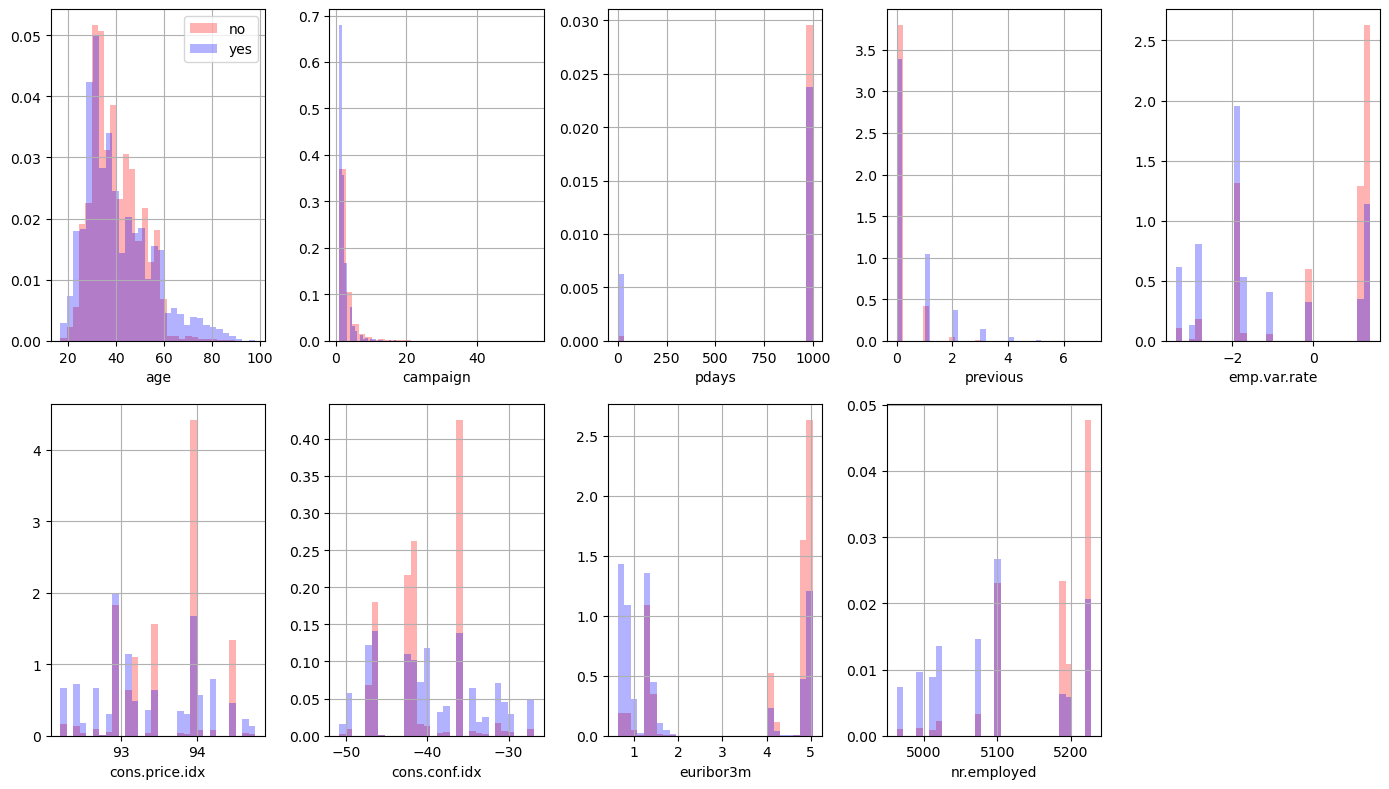

In [31]:
# numerical distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))

for idx, col in enumerate(numerical_cols):
    plt.subplot(2, 5, idx + 1)
    bins = 30
    density = True
    alpha = 0.3

    df[df['y'] == 'no'][col].hist(bins=bins, density=density, alpha=alpha, color="red", label="no")
    df[df['y'] == 'yes'][col].hist(bins=bins, density=density, alpha=alpha, color="blue", label="yes")

    plt.xlabel(col)
    if idx == 0:
        plt.legend()

plt.tight_layout()
plt.show()

### One-Hot Encoding (categorical)

In [33]:
# contact는 값이 2개만 있으므로 0, 1로 one-hot encoding
X['contact'] = X['contact'].map({'cellular': 1, 'telephone': 0})
X_test['contact'] = X_test['contact'].map({'cellular': 1, 'telephone': 0})
categorical_cols = categorical_cols.drop(['contact'], axis=1)
categorical_cols

,job,marital,education,default,housing,loan,month,day_of_week,poutcome
0,technician,married,university.degree,no,yes,yes,aug,thu,nonexistent
1,admin.,single,university.degree,no,yes,no,nov,thu,nonexistent
2,management,divorced,professional.course,no,yes,no,nov,fri,nonexistent
3,blue-collar,single,basic.9y,no,unknown,unknown,jun,wed,nonexistent
4,student,single,basic.9y,no,unknown,unknown,sep,tue,nonexistent
...,...,...,...,...,...,...,...,...,...
32945,admin.,married,university.degree,no,no,yes,may,mon,nonexistent
32946,blue-collar,married,basic.4y,no,no,no,jun,thu,nonexistent
32947,retired,divorced,unknown,no,yes,yes,nov,fri,success
32948,blue-collar,married,high.school,no,no,no,may,wed,nonexistent


In [36]:
X.head()
#X_test.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,36,technician,married,university.degree,no,yes,yes,1,aug,thu,1,999,0,nonexistent,1.4,93.444,-36.1,4.968,5228.1
1,28,admin.,single,university.degree,no,yes,no,1,nov,thu,2,999,0,nonexistent,-3.4,92.649,-30.1,0.714,5017.5
2,57,management,divorced,professional.course,no,yes,no,1,nov,fri,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8
3,24,blue-collar,single,basic.9y,no,unknown,unknown,1,jun,wed,1,999,0,nonexistent,-2.9,92.963,-40.8,1.260,5076.2
4,24,student,single,basic.9y,no,unknown,unknown,1,sep,tue,1,999,0,nonexistent,-3.4,92.379,-29.8,0.788,5017.5


In [38]:
# pdays도 999가 많으므로 999는 0, 나머지는 1로 one-hot encoding
X['pdays_contacted'] = (X['pdays'] != 999).astype(int)
X_test['pdays_contacted'] = (X_test['pdays'] != 999).astype(int)
X = X.drop(columns=['pdays'])
X_test = X_test.drop(columns=['pdays'])

In [40]:
X.head()
#X_test.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_contacted
0,36,technician,married,university.degree,no,yes,yes,1,aug,thu,1,0,nonexistent,1.4,93.444,-36.1,4.968,5228.1,0
1,28,admin.,single,university.degree,no,yes,no,1,nov,thu,2,0,nonexistent,-3.4,92.649,-30.1,0.714,5017.5,0
2,57,management,divorced,professional.course,no,yes,no,1,nov,fri,1,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
3,24,blue-collar,single,basic.9y,no,unknown,unknown,1,jun,wed,1,0,nonexistent,-2.9,92.963,-40.8,1.260,5076.2,0
4,24,student,single,basic.9y,no,unknown,unknown,1,sep,tue,1,0,nonexistent,-3.4,92.379,-29.8,0.788,5017.5,0


In [42]:
X.dtypes

age                  int64
job                 object
marital             object
education           object
default             object
housing             object
loan                object
contact              int64
month               object
day_of_week         object
campaign             int64
previous             int64
poutcome            object
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
pdays_contacted      int64
dtype: object

### Train/Validation Split

In [45]:
random_state = 42

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=random_state
)

In [48]:
X_train.shape, X_valid.shape, y_train.shape, y_valid.shape

((26360, 19), (6590, 19), (26360,), (6590,))

### Normalization

In [50]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64','float64']).columns
categorical_cols, numerical_cols

(Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'month',
        'day_of_week', 'poutcome'],
       dtype='object'),
 Index(['age', 'contact', 'campaign', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
        'pdays_contacted'],
       dtype='object'))

### Numerical

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Train → fit + transform
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[numerical_cols]),
    columns=numerical_cols,
    index=X_train.index
)

# Validation → transform만
X_valid_num = pd.DataFrame(
    scaler.transform(X_valid[numerical_cols]),
    columns=numerical_cols,
    index=X_valid.index
)

# Test → transform만
X_test_num = pd.DataFrame(
    scaler.transform(X_test[numerical_cols]),
    columns=numerical_cols,
    index=X_test.index
)


In [57]:
X_train_num.head()

,age,contact,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_contacted
27262,-0.384499,0.757947,-0.566170,-0.351318,-1.197835,-1.174701,-1.227391,-1.361441,-0.946247,-0.194935
24640,-0.288557,-1.319354,-0.566170,-0.351318,-1.197835,-1.174701,-1.227391,-1.342388,-0.946247,-0.194935
6412,-0.576382,0.757947,-0.206835,-0.351318,-1.197835,-1.174701,-1.227391,-1.326221,-0.946247,-0.194935
11580,-1.535800,0.757947,-0.566170,-0.351318,0.838654,0.592285,-0.471294,0.772524,0.843734,-0.194935
30153,-0.384499,0.757947,0.511833,-0.351318,0.838654,0.592285,-0.471294,0.771947,0.843734,-0.194935


In [59]:
X_train_num.describe()

,age,contact,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_contacted
count,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04,2.636000e+04
mean,6.860134e-17,8.356155e-17,7.587928e-17,-3.396373e-17,2.412503e-17,4.102239e-14,4.434153e-16,4.663274e-17,-5.791355e-15,1.482544e-17
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-2.207392e+00,-1.319354e+00,-5.661697e-01,-3.513183e-01,-2.216080e+00,-2.367632e+00,-2.221119e+00,-1.726340e+00,-2.826421e+00,-1.949349e-01
25%,-7.682655e-01,-1.319354e+00,-5.661697e-01,-3.513183e-01,-1.197835e+00,-8.609533e-01,-4.712938e-01,-1.316406e+00,-9.462467e-01,-1.949349e-01
50%,-1.926151e-01,7.579468e-01,-2.068354e-01,-3.513183e-01,6.477330e-01,3.009476e-01,-2.768688e-01,7.119002e-01,3.289414e-01,-1.949349e-01
75%,6.708606e-01,7.579468e-01,1.524990e-01,-3.513183e-01,8.386538e-01,7.233003e-01,8.896813e-01,7.719468e-01,8.437344e-01,-1.949349e-01
max,5.563890e+00,7.579468e-01,1.919722e+01,1.191187e+01,8.386538e-01,2.055866e+00,2.941945e+00,8.204460e-01,8.437344e-01,5.129918e+00


### Categorical

In [62]:
X_train_cat_raw = X_train[categorical_cols]
X_valid_cat_raw = X_valid[categorical_cols]
X_test_cat_raw  = X_test[categorical_cols]

In [64]:
X_train_cat = pd.get_dummies(X_train_cat_raw, drop_first=False)
X_valid_cat = pd.get_dummies(X_valid_cat_raw, drop_first=False)
X_test_cat  = pd.get_dummies(X_test_cat_raw,  drop_first=False)

In [66]:
X_valid_cat = X_valid_cat.reindex(columns=X_train_cat.columns, fill_value=0)
X_test_cat  = X_test_cat.reindex(columns=X_train_cat.columns,  fill_value=0)

In [68]:
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_valid_final = pd.concat([X_valid_num, X_valid_cat], axis=1)
X_test_final  = pd.concat([X_test_num,  X_test_cat],  axis=1)

In [70]:
X_train_final.shape, X_valid_final.shape, X_test_final.shape

((26360, 61), (6590, 61), (8238, 61))

In [72]:
X_train_final.head()

,age,contact,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_contacted,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
27262,-0.384499,0.757947,-0.566170,-0.351318,-1.197835,-1.174701,-1.227391,-1.361441,-0.946247,-0.194935,...,False,False,False,False,True,False,False,False,True,False
24640,-0.288557,-1.319354,-0.566170,-0.351318,-1.197835,-1.174701,-1.227391,-1.342388,-0.946247,-0.194935,...,False,False,False,True,False,False,False,False,True,False
6412,-0.576382,0.757947,-0.206835,-0.351318,-1.197835,-1.174701,-1.227391,-1.326221,-0.946247,-0.194935,...,False,False,False,False,True,False,False,False,True,False
11580,-1.535800,0.757947,-0.566170,-0.351318,0.838654,0.592285,-0.471294,0.772524,0.843734,-0.194935,...,False,False,False,False,False,False,True,False,True,False
30153,-0.384499,0.757947,0.511833,-0.351318,0.838654,0.592285,-0.471294,0.771947,0.843734,-0.194935,...,False,False,False,False,False,True,False,False,True,False


In [74]:
X_train_final.columns

Index(['age', 'contact', 'campaign', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'pdays_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'marital_unknown', 'education_basic.4y', 'education_basic.6y',
       'education_basic.9y', 'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'education_unknown', 'default_no', 'default_unknown', 'default_yes',
       'housing_no', 'housing_unknown', 'housing_yes', 'loan_no',
       'loan_unknown', 'loan_yes', 'month_apr', 'month_aug', 'month_dec',
       'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov',
       'month_oct', 'month_sep', 'day_of_week_fr

# Training

### K-Fold

In [78]:
from sklearn.model_selection import KFold, GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
scoring = "roc_auc"

models = {}

In [80]:
CV_scores = {}

### Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model = LogisticRegression(solver="saga")

# Define the hyperparameters and their possible values
param_grid = {
    "max_iter": [5000, 10000],
    "penalty": ["l1", "l2"],
    "C": [0.1, 1, 10],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, verbose=1, n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Print the best parameters and the corresponding score
print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Logistic Regression"] = grid_search.best_estimator_
CV_scores["Logistic Regression"] = grid_search.best_score_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters:  {'C': 0.1, 'max_iter': 5000, 'penalty': 'l1'}
Best CV score: 0.793477


### Bagging

In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, StackingClassifier

base_model = DecisionTreeClassifier()
model = BaggingClassifier(estimator=base_model,
                          bootstrap=True,
                          random_state=random_state)

# Define the hyperparameters and their possible values
param_grid = {
    "n_estimators": [50, 100, 200],
    "estimator__max_depth": [None, 10],
    "estimator__min_samples_leaf": [1, 5],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Print the best parameters and the corresponding score
print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Bagging"] = grid_search.best_estimator_
CV_scores["Bagging"] = grid_search.best_score_

Best parameters:  {'estimator__max_depth': 10, 'estimator__min_samples_leaf': 5, 'n_estimators': 200}
Best CV score: 0.803235


### RandomForest

In [91]:
model = RandomForestClassifier(bootstrap=True,
                               n_jobs=-1,
                               random_state=random_state)

# Define the hyperparameters and their possible values
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_features": [0.5, "sqrt", "log2"],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, n_jobs=-1)
grid_search.fit(X_train_final, y_train)

# Print the best parameters and the corresponding score
print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Random Forest"] = grid_search.best_estimator_
CV_scores["Random Forest"] = grid_search.best_score_

Best parameters:  {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV score: 0.802521


### Gradient Boosting

In [93]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(
    subsample=1.0,
    random_state=random_state
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 6],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring, n_jobs=-1)
grid_search.fit(X_train_final, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["Gradient Boosting"] = grid_search.best_estimator_
CV_scores["Gradient Boosting"] = grid_search.best_score_

Best parameters:  {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}
Best CV score: 0.804101


### XGBoost

In [100]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.1 MB/s eta 0:00:00


In [104]:
from xgboost import XGBClassifier 

model = XGBClassifier(
                      n_estimators=50,
                      learning_rate=0.1,
                      n_jobs=-1,
                      random_state=random_state,
                      objective="binary:logistic", 
                      eval_metric="logloss"
                  )

param_grid = {
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 1.0],
}

grid_search = GridSearchCV(model, param_grid, cv=kf, scoring=scoring)
grid_search.fit(X_train_final, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["XGBoost"] = grid_search.best_estimator_
CV_scores["XGBoost"] = grid_search.best_score_

Best parameters:  {'colsample_bytree': 1.0, 'max_depth': 5, 'reg_alpha': 0.1, 'reg_lambda': 0, 'subsample': 1.0}
Best CV score: 0.804138


### LightGBM

In [109]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.0 MB/s eta 0:00:00


In [111]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
                      n_estimators=50,
                      learning_rate=0.1,
                      data_sample_strategy="goss",
                      top_rate=0.2,
                      other_rate=0.1,
                      force_col_wise=True,
                      verbosity=0,
                      n_jobs=-1,
                      random_state=random_state,
                      objective="binary",
                      metric="auc"
                  )

param_grid = {
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 0.1],
    "enable_bundle": [True, False],
    "num_leaves": [31, 63],
    "min_child_samples": [20, 50],
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=kf,
    scoring=scoring,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train_final, y_train)

print("Best parameters: ", grid_search.best_params_)
print("Best CV score: {:.6f}".format(grid_search.best_score_))

models["LightGBM"] = grid_search.best_estimator_
CV_scores["LightGBM"] = grid_search.best_score_


Best parameters:  {'enable_bundle': True, 'min_child_samples': 50, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 0}
Best CV score: 0.803878


In [113]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(C=0.1, max_iter=5000, penalty='l1', solver='saga')), ('Bagging', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=10,
                                                   min_samples_leaf=5),
                  n_estimators=200, random_state=42)), ('Random Forest', RandomForestClassifier(max_depth=10, max_features=0.5, min_samples_leaf=10,
                       n_jobs=-1, random_state=42)), ('Gradient Boosting', GradientBoostingClassifier(learning_rate=0.05, max_depth=6, random_state=42)), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, 

In [125]:
df_cv = pd.DataFrame(CV_scores.items())
df_cv

,0,1
0,Logistic Regression,0.793477
1,Bagging,0.803235
2,Random Forest,0.802521
3,Gradient Boosting,0.804101
4,XGBoost,0.804138
5,LightGBM,0.803878


### Stacking

In [129]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

selected_model_names = ["Logistic Regression", "Bagging", "XGBoost", "LightGBM"]

base_models = [(name, models[name]) for name in selected_model_names]

meta_learner = LogisticRegression(max_iter=500)

stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=kf,           
    passthrough=False
)

stacking_classifier.fit(X_train_final, y_train)

models["Stacking"] = stacking_classifier

### Save Model

In [85]:
from joblib import dump

dump(models, "all_models.joblib")

['all_models_1206.joblib']

In [82]:
from joblib import load

models = load("all_models.joblib")
print(models.keys())

dict_keys(['Logistic Regression', 'Bagging', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'Stacking'])


# Validation

In [85]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [87]:
results = []

### Accuracy, F1, ROC_AUC

In [90]:
import numpy as np

thresholds = np.arange(0.05, 0.51, 0.01)
results = []

for name, model in models.items():
    # 1) 이 모델의 예측 확률
    y_proba = model.predict_proba(X_valid_final)[:, 1]

    # 2) 이 모델에 대해 best threshold 찾기
    best_th = 0.5
    best_f1 = 0.0

    for th in thresholds:
        y_pred_tmp = (y_proba >= th).astype(int)
        f1_tmp = f1_score(y_valid, y_pred_tmp)
        if f1_tmp > best_f1:
            best_f1 = f1_tmp
            best_th = th

    # 3) 찾은 best_th로 최종 예측 & 점수 계산
    y_pred = (y_proba >= best_th).astype(int)

    acc = accuracy_score(y_valid, y_pred)
    f1  = f1_score(y_valid, y_pred)
    auc = roc_auc_score(y_valid, y_proba)

    mean_score = (acc + f1 + auc) / 3

    results.append({
        "Model": name,
        "Best_th": best_th,
        "Accuracy": acc,
        "F1": f1,
        "AUC": auc,
        "Mean(Acc+F1+AUC)/3": mean_score
    })

In [91]:
results_df = pd.DataFrame(results).set_index("Model").sort_values(
    by="Mean(Acc+F1+AUC)/3", ascending=False
)

results_df

,Best_th,Accuracy,F1,AUC,Mean(Acc+F1+AUC)/3
Model,,,,,
Stacking,0.15,0.876328,0.512851,0.795298,0.728159
LightGBM,0.24,0.878907,0.512821,0.792304,0.728011
Bagging,0.20,0.874052,0.509456,0.797762,0.727090
XGBoost,0.23,0.877238,0.508804,0.790416,0.725486
Random Forest,0.20,0.871775,0.507863,0.795636,0.725091
Gradient Boosting,0.17,0.871472,0.501471,0.790973,0.721305
Logistic Regression,0.23,0.876176,0.491905,0.783797,0.717293


### Confusion Matrix

In [95]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_valid, y_pred)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    columns=["Predicted 미가입", "Predicted 가입"],
    index=["Actual 미가입", "Actual 가입"]
)
print(conf_matrix_df)

            Predicted 미가입  Predicted 가입
Actual 미가입           5346           502
Actual 가입             313           429


### Light GBM을 통한 변수 중요도 확인

In [103]:
imp = models["LightGBM"].feature_importances_
importances = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": imp
}).sort_values("importance", ascending=False)
importances.head(10)

,feature,importance
7,euribor3m,292
0,age,265
2,campaign,146
5,cons.price.idx,92
6,cons.conf.idx,60
1,contact,43
54,day_of_week_mon,40
4,emp.var.rate,34
8,nr.employed,34
9,pdays_contacted,26


# Predict

In [100]:
model = "Stacking"

In [102]:
stacking = models[model]

In [104]:
pred_th = results_df["Best_th"][model]
pred_th

0.15000000000000002

In [106]:
y_proba = stacking.predict_proba(X_test_final)[:, 1]
y_predict = (y_proba >= pred_th).astype(int)

print(len(df_test), len(X_test_final), len(y_proba), len(y_predict))

8238 8238 8238 8238


In [108]:
prediction_df = pd.DataFrame({
    "id": df_test["id"],
    "y_predict": y_predict,
    "y_prob": y_proba
})

prediction_df.to_csv("prediction.csv", index=False)

prediction_df.head()

,id,y_predict,y_prob
0,8626,0,0.060304
1,6749,0,0.047519
2,7227,0,0.052262
3,12558,0,0.056721
4,9628,0,0.050441
